# Code: Time Series Decomposition

*Prepared by Michael Lawrence Castanares, PhD*

Note: Most of the contents are taken from my MSDS Time Series class taught by Prof. Sebastian Ibanez, PhD

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf


In [4]:
file = 'data/australian-petroleum-statistics-data-extract-november-2025.xlsx'

df_gas = pd.read_excel(file,
                       sheet_name = "Exports volume",
                       parse_dates=['Month'],
                       na_values=['n.a.'],)
df_gas.rename(columns={'Month': 'ds'}, inplace=True)
df_gas.dropna(inplace=True)
df_gas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 60 to 184
Data columns (total 15 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   ds                                                        125 non-null    datetime64[ns]
 1   Crude oil & other refinery feedstocks (ML)                125 non-null    float64       
 2   LPG (ML)                                                  125 non-null    float64       
 3   Automotive gasoline (ML)                                  125 non-null    float64       
 4   Aviation gasoline (ML)                                    125 non-null    float64       
 5   Aviation turbine fuel (ML)                                125 non-null    float64       
 6   Kerosene (ML)                                             125 non-null    int64         
 7   Diesel oil (ML)                                 

In [5]:
# Helper functions

from fileinput import filename

# Chart template decorator
def apply_chart_template(filename=None):
    """
    Decorator to apply minimal plot styling by removing spines and the y-axis.
    """
    def decorator(func):
        def wrapper(*args, **kwargs):
            result = func(*args, **kwargs)
            for spine in ['top', 'right', 'left']:
                plt.gca().spines[spine].set_visible(False)
            #remove x-labels
            plt.xlabel('')  # Remove x-axis title
            plt.gca().axes.get_yaxis().set_visible(False)
            plt.tight_layout()
            if filename:
                plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            return result
        return wrapper
    return decorator

### Dataset: Australian Export of Liquified Natural Gas (LNG) [volume / in Megaliter]

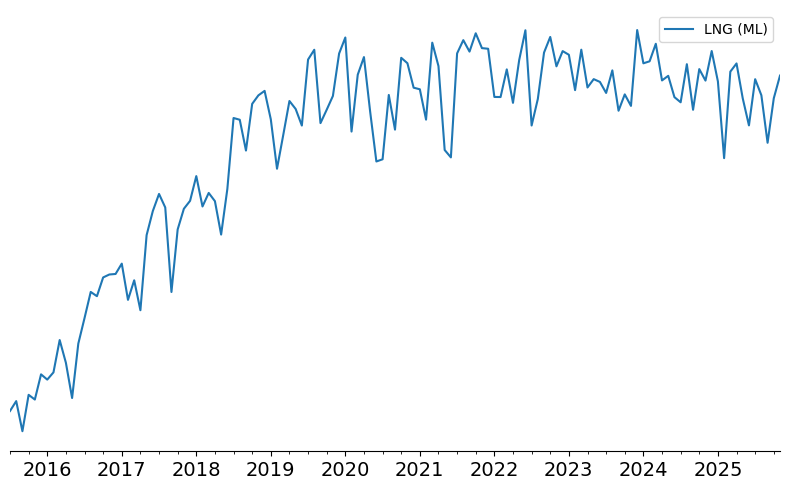

In [6]:
@apply_chart_template(filename='figures/1_gas_exports.png')
def plot():
    df_gas[['ds','LNG (ML)']].plot(x='ds',
                                   y='LNG (ML)',
                                   figsize=(8,5),
                                   fontsize=14,)
plot()
#save figure


### Tool 1: Moving Average (MA)

A moving average (MA) is classical approach to extract the trend-cycle component of the series. A MA of order $m$ is defined as

\begin{align*}
    \hat{T}_t &= \frac{1}{m} \sum_{j=-k}^{k} y_{t+j}
\end{align*}

where $m = 2k + 1$. In other words, the estimate of the trend-cycle at time $t$ is obtained by averaging the time series values within $k$ periods of $t$. This is also known as a centered moving average or an $m-$MA.

The figure below shows the resulting 6-month and 12-month MA of the `AU_LNG`. Note that a larger order $m$ results to a smoother series emphasizing more the trend component.

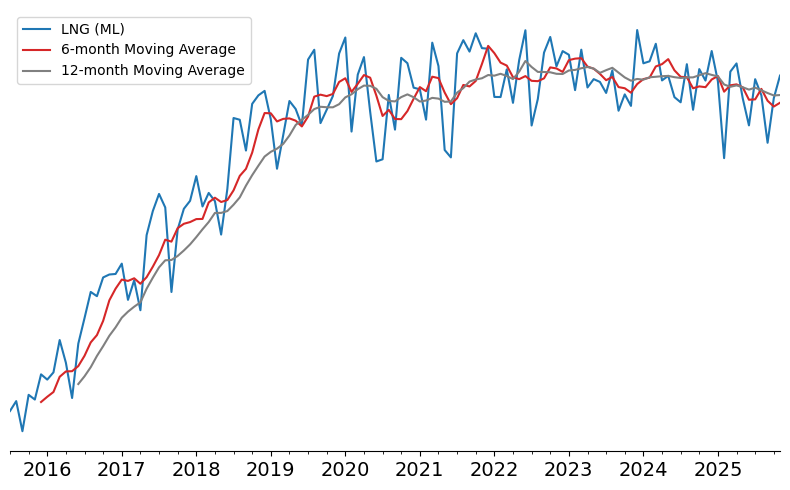

In [7]:
#apply rolling widow (6-month MA)
df_gas['6-MA'] = df_gas['LNG (ML)'].rolling(window=6).mean()
df_gas['12-MA'] = df_gas['LNG (ML)'].rolling(window=12).mean()

@apply_chart_template(filename='figures/2_MA.png')
def plot():
    fig, ax = plt.subplots(figsize=(8,5))
    df_gas[['ds','LNG (ML)']].plot(x='ds',
                                   y='LNG (ML)',
                                   ax = ax,                                   fontsize=14,)
    
    df_gas.plot(x='ds',
                y='6-MA',
                color = 'tab:red',
                label='6-month Moving Average',
                ax=ax)
    df_gas.plot(x='ds',
                y='12-MA',
                label = '12-month Moving Average',
                color = 'grey',
                ax=ax)
plot()

### Tool 2: Seasonal Trend Decomposition using LOESS (STL) decomposition. 
Developed by R.B. Cleveland et al (1990), this method is a versatile and robust method for decomposition. LOESS (locally estimated scatterplot smoothing) is a method for estimating nonlinear relationships.

The key advantages of STL are:
* Allows for the seasonal component to change over time wherein the rate of change can be controlled by the user
* Smoothness of the Trend-cycle can also be set by the user
* It is robust to outliers and will be part of the remainder.

We can use Python statsmodels library to carry-out STL decomposition. The figure below shows the resulting trend, cycle, and residual component after applying STL (Panel a). 


See the statsmodels [API](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html) for details of the parameters.


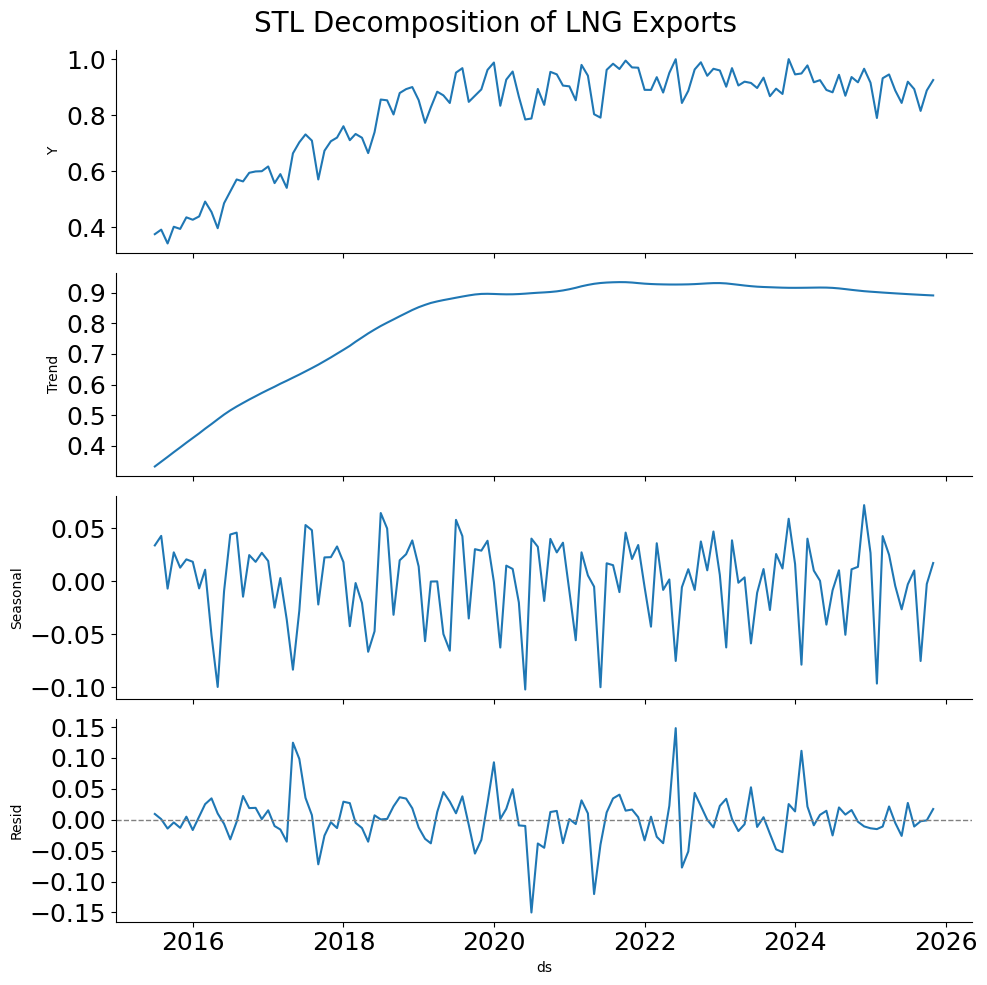

In [151]:
df_gas['LNG (ML)'] = df_gas['LNG (ML)'] / max(df_gas['LNG (ML)'])

res = STL(df_gas['LNG (ML)'],
          period=12,
          robust=True,
          ).fit()

df_dcmp = pd.DataFrame({
    'ds': df_gas["ds"],
    'y': df_gas["LNG (ML)"],
    'trend': res.trend,
    'seasonal': res.seasonal,
    "resid": res.resid
}).reset_index(drop=True)
df_dcmp.set_index('ds', inplace=True)

fig, axes = plt.subplots(nrows=4,
                         ncols=1,
                         sharex=True,
                         figsize=(10, 10))

y_vars = ['y', 'trend', 'seasonal', 'resid']

for i, var in enumerate(y_vars):
    sns.lineplot(data=df_dcmp,
                 x='ds',
                 y=var,
                 ax=axes[i])
    axes[i].set_ylabel(var.capitalize())

#set all font size for this figure only
for ax in axes:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(18)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    # ax.get_yaxis().set_visible(False)

axes[-1].axhline(y=0, 
               color='grey', 
               linestyle='--', 
               linewidth=1)

fig.suptitle('STL Decomposition of LNG Exports', fontsize=20)
fig.tight_layout()
plt.show()
fig.savefig('figures/3_STL_decomposition.png',
            dpi=300,
            bbox_inches='tight')

#### Is the seasonal component robust across years?

The seasonal plot showing the levels of the seasonal component for the same month cross different years also indicate how robust/predictable the cyclic pattern is. Ideally, the levels of cyclic component would be the same for the same month but real-world data always tend to deviate from ideal assumptions. 

/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_1774/1891116581.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


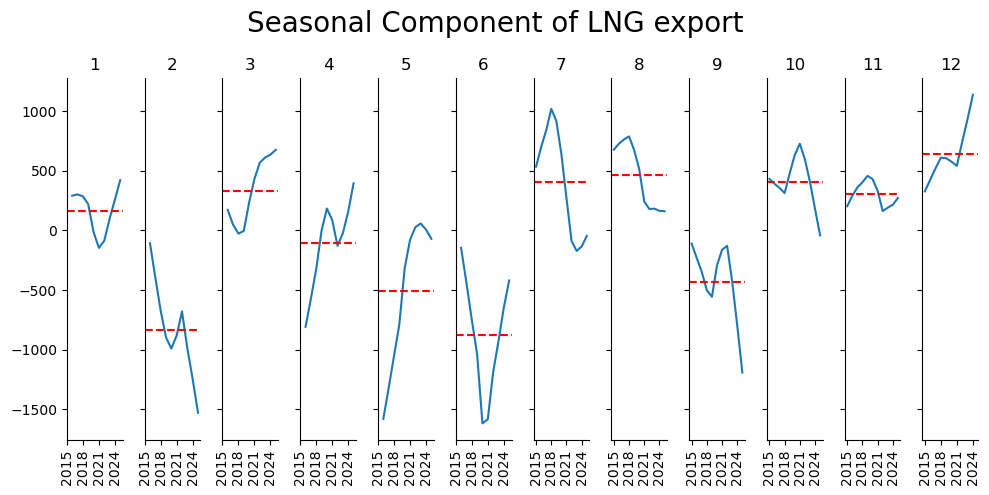

In [13]:
#plot the seasonal component per month per year

df_dcmp['month'] = df_dcmp.index.month
df_dcmp['year'] = df_dcmp.index.year

df_grp = (df_dcmp.groupby(['year', 'month'])['seasonal']
    .mean()
    .unstack())

fig, ax = plt.subplots(1, 12, figsize=(10,5), sharey=True)
for i, col in enumerate(df_grp.columns):
    df_grp[col].plot(ax=ax[i], title=col)
    mean = df_grp[col].mean()
    ax[i].axhline(mean, color='red', linestyle='--')


#rotate x-axis labels
for i, ax_i in enumerate(ax):
    ax_i.set_xticks(df_grp.index)
    ax_i.set_xticklabels(df_grp.index, rotation=90)
    
    #reduce number of x-ticks
    ax_i.set_xticks(df_grp.index[::3])
    
    #hide x-axis title
    ax_i.set_xlabel('')

    #remove bounding box
    ax_i.spines['top'].set_visible(False)
    ax_i.spines['right'].set_visible(False)


fig.suptitle('Seasonal Component of LNG export', fontsize=20)
fig.tight_layout()
fig.show()
fig.savefig('figures/4_seasonal_component.png',
            dpi=300,
            bbox_inches='tight')

#### How do you check if you get the right decomposition? Check auto-correlation of residuals

**insight:** To check for the quality of the decomposition, we can look at the auto-correlation function (ACF) of the residual. The ACF shows that there are significant auto-correlations of the residual at its 1-month, 3-month, and 8-month lag. This suggest that there is still some information(signal) that were not captured. Researchers can fine-tune the STL parameters or explore other decomposition methods.

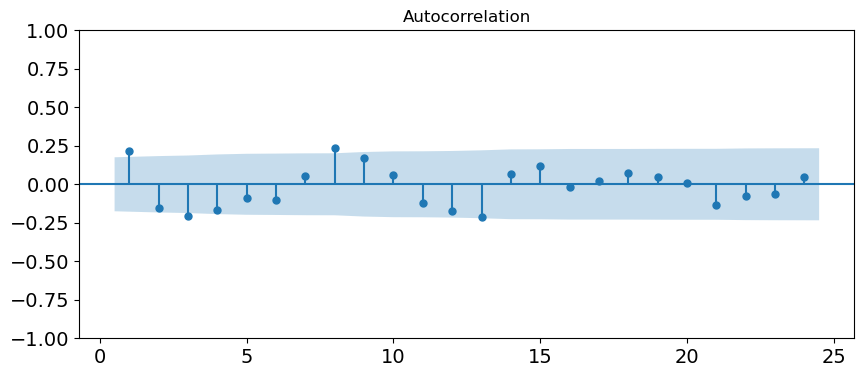

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df_dcmp['resid'],
            zero=False,
            lags=24,
            ax=ax)
#set all font size for this figure only
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(14)
plt.show()
fig.savefig('figures/5_ACF_residuals.png',
            dpi=300,
            bbox_inches='tight')

### Tool 3: Prophet model

Introduced by Facebook  ([S. J. Taylor & Letham, 2018](https://doi.org/10.1080/00031305.2017.1380080)). An pre-print of the paper can be found [here](https://peerj.com/preprints/3190v2.pdf). [Prophet] (https://facebook.github.io/prophet/) is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects.


Prophet can be viewed as a nonlinear regression model of the form:

\begin{align*}
    y_t &= g(t) + s(t) + h(t) + \varepsilon_t
\end{align*}

where:
- $g(t)$ is the trend function, which models non-periodic changes. By default, it is a piecewise-linear "growth term."
- $s(t)$ describes the seasonal patterns (e.g., yearly, weekly)
- $h(t)$ represents the effects of holidays or other irregular events.
- $\varepsilon_t$ is the error term, assumed to be white noise.

#### Inclusion of holiday information
The strength of the Prophet model is the inclusion of holiday information in the analysis. We account for holidays (i.e., number of holidays per month) in Australia as part of the decomposition procedure.

In [152]:
### Prophet STL Decomposition

from prophet.make_holidays import make_holidays_df
from prophet import Prophet

df_p = df_gas[['ds', 'LNG (ML)']].copy()
df_p.rename(columns={'LNG (ML)': 'y'}, inplace=True)
df_p.reset_index(inplace=True, drop=True)
df_p

df_holidays = make_holidays_df(
    year_list=[2015 + i for i in range(11)],
    country='AU',
)

display(df_holidays.head())
df_holidays.sort_values('ds',
                        ascending=True,
                        inplace=True)
df_holidays.reset_index(drop=True, inplace=True)

#
'''
Here we convert the dates to first day of the month
as the `AU_LNG` series is monthly. This informs prophet
the number of holidays in a given month.
'''

tmp = df_holidays.copy()
tmp['ds'] = (tmp['ds']
                     .dt
                     .to_period('M')
                     .dt
                     .to_timestamp())


tmp = (tmp
        .groupby('ds')
        .size()
        .reset_index(name='count')
        .sort_values('ds', ascending=True))

df_p.set_index('ds', inplace=True)
tmp.set_index('ds', inplace=True)
df_p['holiday_count'] = tmp['count']
df_p.fillna(0, inplace=True)
df_p.reset_index(inplace=True)

df_p.head(30)

,ds,holiday
0,2016-03-25,Good Friday
1,2016-03-28,Easter Monday
2,2016-01-01,New Year's Day
3,2016-01-26,Australia Day
4,2016-04-25,ANZAC Day


,ds,y,holiday_count
0,2015-07-01,0.376137,0.0
1,2015-08-01,0.392329,0.0
2,2015-09-01,0.343029,0.0
3,2015-10-01,0.402629,0.0
4,2015-11-01,0.394898,0.0
5,2015-12-01,0.436153,2.0
6,2016-01-01,0.427560,2.0
7,2016-02-01,0.439402,0.0
8,2016-03-01,0.492354,2.0
9,2016-04-01,0.455153,1.0


11:19:25 - cmdstanpy - INFO - Chain [1] start processing
11:19:25 - cmdstanpy - INFO - Chain [1] done processing


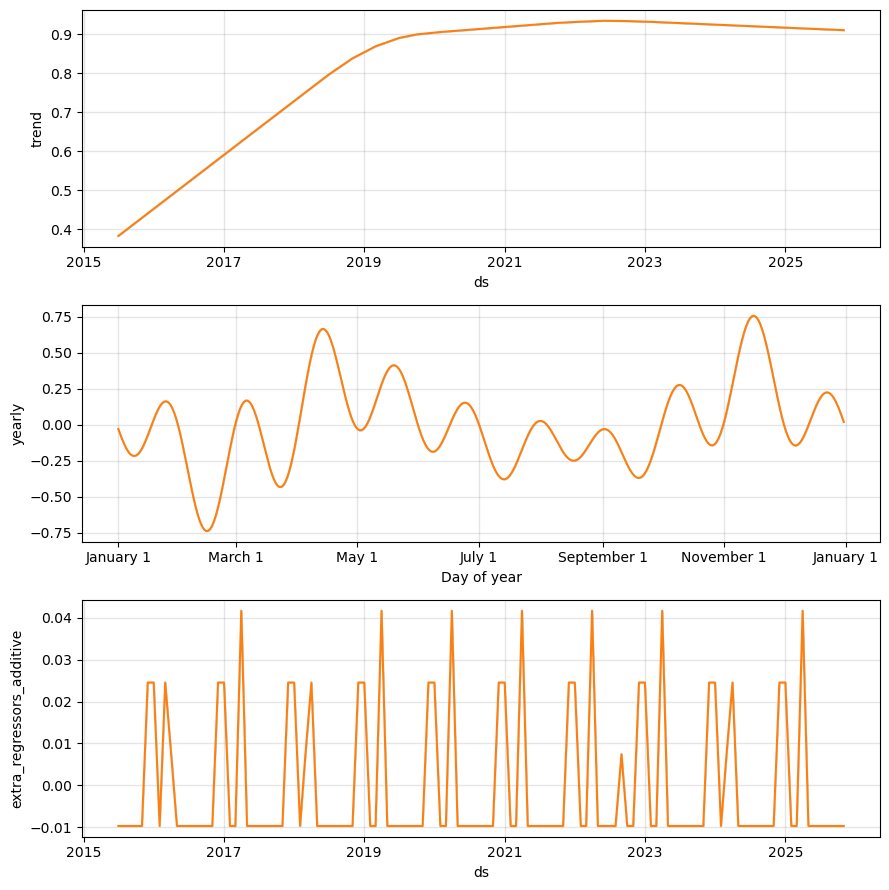

Text(0.5, 1.0, 'Residuals over Time')

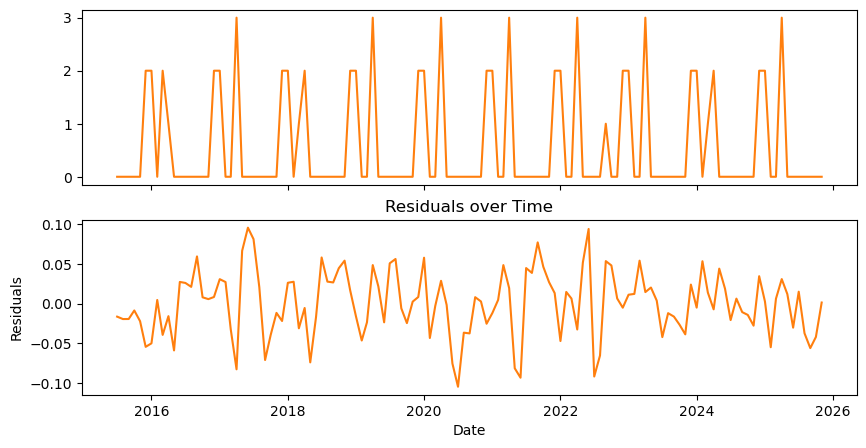

In [134]:
model = Prophet()
df_p['y'] = df_p['y']/max(df_p['y'])
model.add_regressor('holiday_count')
model.fit(df_p)
fitted = model.predict()

fitted.index = df_p.ds
fitted['resid'] = df_p.set_index('ds').y - fitted['yhat']

model.plot_components(fitted)

#set color to orange
for ax in plt.gcf().axes:
    for line in ax.get_lines():
        line.set_color('tab:orange')
plt.tight_layout()
plt.show()


#include residual
fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True)

ax[0].plot(df_p['ds'], df_p['holiday_count'], color='tab:orange')

ax[1].plot(fitted['ds'], fitted['resid'], color='tab:orange')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals over Time')

In [142]:
fitted.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'extra_regressors_additive', 'extra_regressors_additive_lower',
       'extra_regressors_additive_upper', 'holiday_count',
       'holiday_count_lower', 'holiday_count_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat', 'resid'],
      dtype='object')

,y,holiday_count,trend,seasonal,holiday,resid
ds,,,,,,
2015-07-01,0.376137,0.0,0.382363,0.019870,-0.009738,-0.016358
2015-08-01,0.392329,0.0,0.394109,0.027357,-0.009738,-0.019399
2015-09-01,0.343029,0.0,0.405855,-0.033760,-0.009738,-0.019329
2015-10-01,0.402629,0.0,0.417222,0.003745,-0.009738,-0.008601
2015-11-01,0.394898,0.0,0.428968,-0.002210,-0.009738,-0.022122


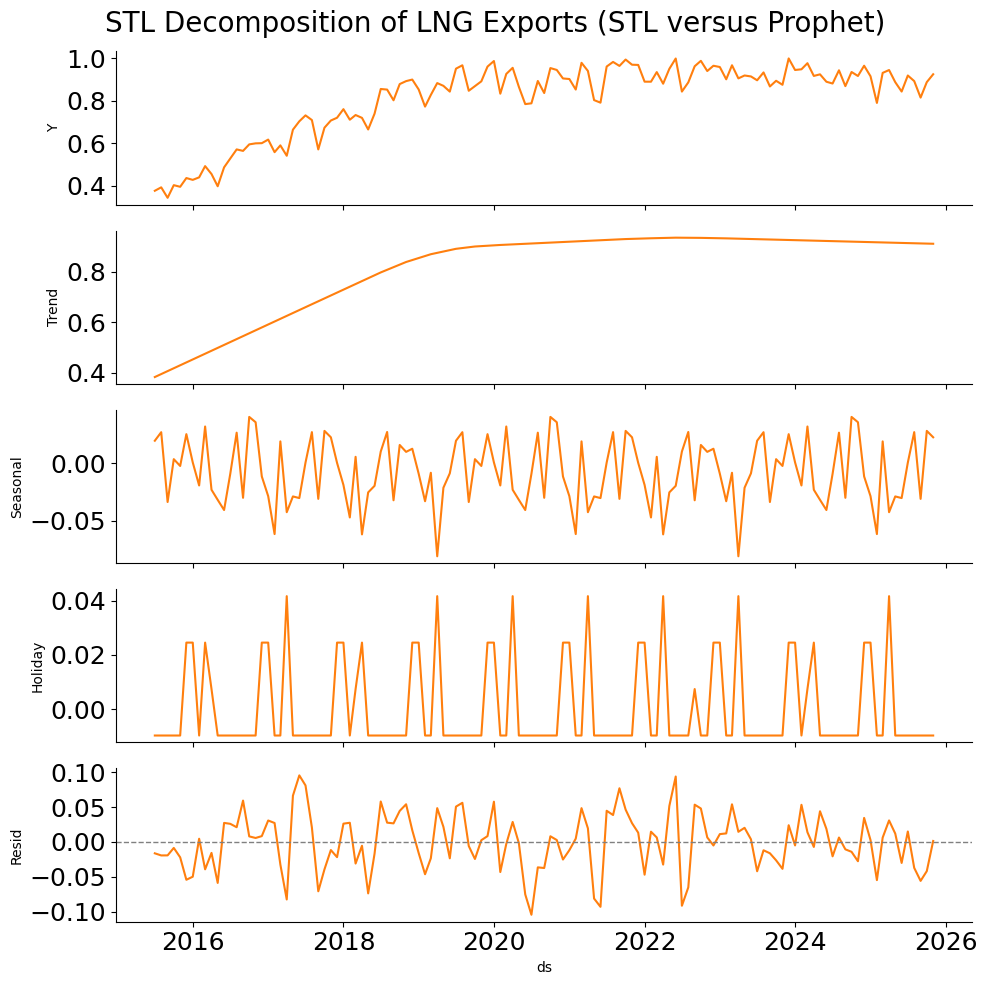

In [150]:
df_dcmp_pr = df_p.set_index('ds').copy()
df_dcmp_pr['trend'] = fitted['trend']
df_dcmp_pr['seasonal'] = fitted['yearly']
df_dcmp_pr['holiday'] = fitted['extra_regressors_additive']
df_dcmp_pr['resid'] = fitted['resid']

display(df_dcmp_pr.head())
fig, axes = plt.subplots(nrows=5,
                         ncols=1,
                         sharex=True,
                         #sharey=True,
                         figsize=(10, 10))

y_vars = ['y', 'trend', 'seasonal', 'holiday','resid']

for i, var in enumerate(y_vars):
    sns.lineplot(data=df_dcmp_pr,
                 x='ds',
                 y=var,
                 color='tab:orange',
                 ax=axes[i])
    axes[i].set_ylabel(var.capitalize())

#set all font size for this figure only
for ax in axes:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(18)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.spines['left'].set_visible(False)
    #ax.get_yaxis().set_visible(False)

#draw horizontal line at y=0 for residuals
axes[-1].axhline(y=0, 
               color='grey', 
               linestyle='--', 
               linewidth=1)

fig.suptitle('STL Decomposition of LNG Exports (STL versus Prophet)', fontsize=20)
fig.tight_layout()
plt.show()
fig.savefig('figures/6_STL_decomposition_pr.png',
            dpi=300,
            bbox_inches='tight')

/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_1774/2908600075.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


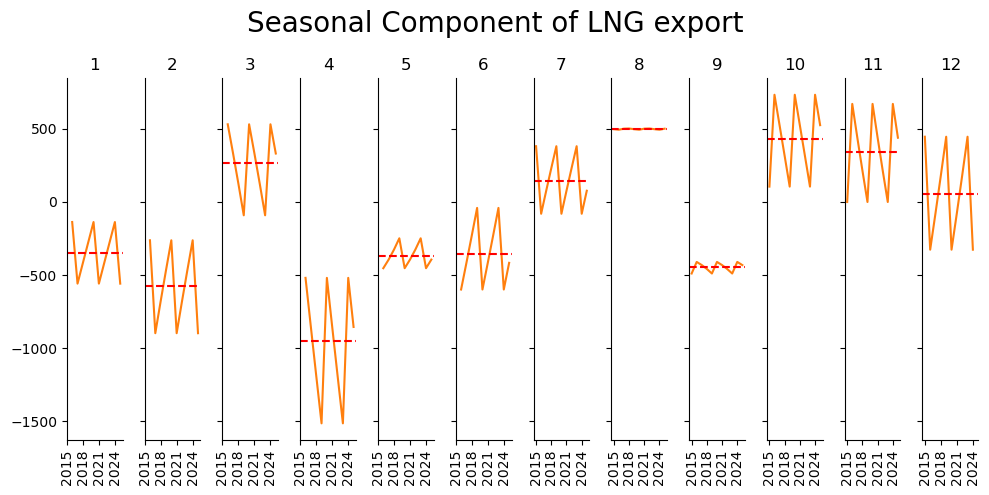

In [131]:
#plot the seasonal component per month per year

df_dcmp_pr['month'] = df_dcmp_pr.index.month
df_dcmp_pr['year'] = df_dcmp_pr.index.year

df_grp = (df_dcmp_pr.groupby(['year', 'month'])['seasonal']
    .mean()
    .unstack())

fig, ax = plt.subplots(1, 12, figsize=(10,5), sharey=True)
for i, col in enumerate(df_grp.columns):
    df_grp[col].plot(ax=ax[i],
                     title=col,
                     color='tab:orange')
    mean = df_grp[col].mean()
    ax[i].axhline(mean, color='red', linestyle='--')


#rotate x-axis labels
for i, ax_i in enumerate(ax):
    ax_i.set_xticks(df_grp.index)
    ax_i.set_xticklabels(df_grp.index, rotation=90)
    
    #reduce number of x-ticks
    ax_i.set_xticks(df_grp.index[::3])
    
    #hide x-axis title
    ax_i.set_xlabel('')

    #remove bounding box
    ax_i.spines['top'].set_visible(False)
    ax_i.spines['right'].set_visible(False)


fig.suptitle('Seasonal Component of LNG export', fontsize=20)
fig.tight_layout()
fig.show()
fig.savefig('figures/4_seasonal_component.png',
            dpi=300,
            bbox_inches='tight')

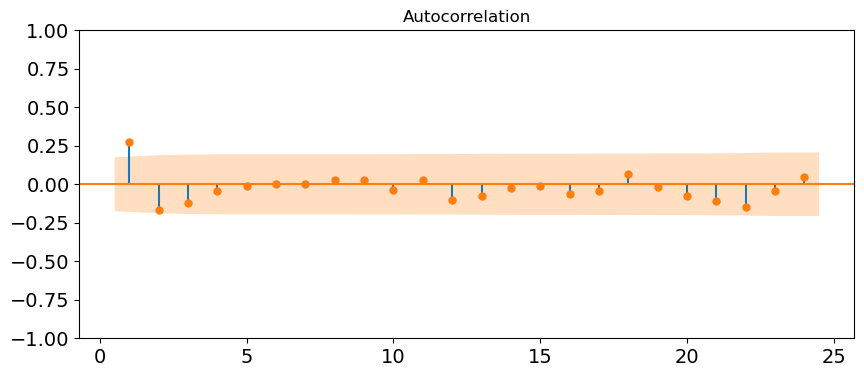

In [132]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df_dcmp_pr['resid'],
            zero=False,
            lags=24,
            color='tab:orange',
            ax=ax)
#set line and fill color to orange in acf
ax.collections[1].set_facecolor('tab:orange')

#set all font size for this figure only
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(14)
plt.show()
fig.savefig('figures/7_ACF_residuals_pr.png',
            dpi=300,
            bbox_inches='tight')

* Prophet decomposition shows a more robust extraction of the signal. We can see from the ACF, there is minimal serial correlation of the residuals except at lags 1 and 2 months. This can be addressed in the modelling